**Group Contribution**

Lorenzo Montin (2148497) - Open questions, 2.1, 2.2 & 3

Jeroen van de Sande (2146540) - 1 & open questions

Jord Wokke (2082511)- Open questions, 2.3 & 2.4

This assignment asks you to partly reproduce a DSS thesis submitted in the summer of 2025 titled

**Investigating gender bias in Large Language Models through Dutch text generation: Assessing the role of embeddings, pre-training, and alignment within LLaMa models on gender bias**

by *Matthijs ten Thije*

For some tasks you can directly use the original code, for others you will need to code something yourself, for others you can rely on the original code base but will have to adapt it. The points awarded are specified next to each task, with an indication of whether partial points are allowed. When they are, a rubric exists for each answer to ensure a fair grading process.

The assignment consists of the following tasks:

- **TASK 1 (15 points),** an analysis of gender bias in the static representations learned by a contextualised multilingual embedding model, (Multilingual BERT), to see which Dutch words are more strongly associated with female versus male concepts and visualize your results.
- **OPEN QUESTIONS (15 points)**, where you'll be asked to answer some questions about the outcome of TASK 1 and draw comparisons with the results reported in the thesis;
- **TASK 2 (25 POINTS),** an analysis of sense-specific gender bias using contextualised embedding models and the representations they produce for words in context;
- **TASK 3 (10 POINTS),** a classification study conducted on artificially generated sentences that exhibit stereotypical and non-stereotypical gender associations
- **EXTRA TASK (10 POINTS),** a more difficult task you can engage with if you wish to delve deeper into these types of work or to try and gain back some points. See details at the end of the notebook.

In [85]:
# you will need this library
!pip install datasets

# the solution has been partly developed using the minicons library, but this is not necessary.
# You can use alternative options or code from scratch.
!pip install minicons

In [86]:
# if you use minicons, then you'll need this import
from minicons import cwe

# add other imports here
import os
from transformers import BertTokenizer, BertModel
import numpy as np


In [87]:
os.getcwd()

'/content'

In [88]:
# this is necessary to sync up colab and drive to access files.
from google.colab import drive
drive.mount('/content/drive/')

Drive already mounted at /content/drive/; to attempt to forcibly remount, call drive.mount("/content/drive/", force_remount=True).


In [89]:
import pandas as pd

# Path to your files
adjectives_path = '/content/drive/My Drive/Colab Notebooks/NLP Assignment Data/Corpus_Hedendaags_Nederlands_Adjectives_recovered.csv'
sentences_path = '/content/drive/My Drive/Colab Notebooks/NLP Assignment Data/sentences_cleaned.csv'

# Create DataFrames
df_adjectives = pd.read_csv(adjectives_path)
df_sentences = pd.read_csv(sentences_path)

# Quick check
print(df_adjectives.head())
#print(df_sentences.head())





    adjective
0       groot
1      vreemd
2    prachtig
3  onschuldig
4  vrouwelijk


**TASK 1 (15 points)**

Reproduce the pipeline from the thesis to compute word embedding bias from the static representations learned by the cased version of the Multilingual BERT model (M-BERT):


1.1. load the model (1pt, assigned for correctly loading the right model)

1.2. load the target adjectives (1 pt, assigned for correctly loading the right strings)

1.3. load the target male and female words (1 pt, assigned for correctly loading the right strings)

1.4. extract static embeddings for the necessary words (3 pts, assigned for correct static embeddings)

1.5. compute each word's bias and the permutation-based p-value, then z-standardize the bias scores (5pts, assigned for correct bias scores, p-values and z-scores - partial points allowed, if, e.g., bias and p-value are correct but z-scores aren't)

1.6. visualize bias for M-BERT, choosing the most appropriate data viz (4 pts, assigned base on appropriateness and correctness of the visualization - partial points allowed)

In [90]:
# 1.1.load cased M-BERT using the HuggingFace library
# M-BERT is a Masked Language Model and it is to be used for encoding strings,
# not for classification purposes, so choose the right class when loading it!
from transformers import BertTokenizer, BertModel
multilingual_bert = BertModel.from_pretrained('bert-base-multilingual-cased')
tokenizer = BertTokenizer.from_pretrained('bert-base-multilingual-cased')

In [91]:
# check the model specs to find out the embedding size
multilingual_bert.eval()

BertModel(
  (embeddings): BertEmbeddings(
    (word_embeddings): Embedding(119547, 768, padding_idx=0)
    (position_embeddings): Embedding(512, 768)
    (token_type_embeddings): Embedding(2, 768)
    (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
    (dropout): Dropout(p=0.1, inplace=False)
  )
  (encoder): BertEncoder(
    (layer): ModuleList(
      (0-11): 12 x BertLayer(
        (attention): BertAttention(
          (self): BertSdpaSelfAttention(
            (query): Linear(in_features=768, out_features=768, bias=True)
            (key): Linear(in_features=768, out_features=768, bias=True)
            (value): Linear(in_features=768, out_features=768, bias=True)
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (output): BertSelfOutput(
            (dense): Linear(in_features=768, out_features=768, bias=True)
            (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
            (dropout): Dropout(p=0.1, inplace=Fals

In [92]:
# 1.2. import target Dutch adjectives
adjectives = df_adjectives['adjective']
list_adjectives = list(adjectives)

# print the first 5 target adjectives (sorted alphabetically)
print(sorted(list(adjectives))[:5])

['aaibare', 'aanbiddelijk', 'aandachtig', 'aandoenlijk', 'aangenaam']


In [93]:
print(list_adjectives[:15])

['groot', 'vreemd', 'prachtig', 'onschuldig', 'vrouwelijk', 'angstig', 'koppig', 'uitzonderlijk', 'verkiesbaar', 'wilsonbekwame', 'ongerust', 'polygaum', 'wereldwijaz', 'praatgraag', 'teder']


In [94]:
# 1.3. import the Dutch male and female words used in the original thesis
male_words = ["man","kerel","jongen","vader", "zoon", "vent","meneer","opa","oom"]
female_words = ["vrouw", "dame","meisje","moeder","dochter","meid", "mevrouw","oma","tante"]

# print them
print(female_words)
print(male_words)

['vrouw', 'dame', 'meisje', 'moeder', 'dochter', 'meid', 'mevrouw', 'oma', 'tante']
['man', 'kerel', 'jongen', 'vader', 'zoon', 'vent', 'meneer', 'opa', 'oom']


In [95]:
# I provide here a short how-to of how to access static embeddings, with concise
# explanations of things to be mindful of.

# this command allows you to access the static embeddings, assuming you called
# the instance of the model multilingual_bert in task 1.1
embedding_layer = multilingual_bert.get_input_embeddings()

# remember that every input string gets tokenised, and sometimes a single word
# gets encoded as a list of two or more tokens, see 'gompemburg' below
print(tokenizer.tokenize("{}".format('gompemburg')))

# the .encode() methods yields the list of tokens as numerical indices in the
# embedding layer. However, notice that .encode() produces 5 indices, whereas
# .tokenize() produced 3 tokens! What might the extra tokens be and which are they?
print(tokenizer.encode("{}".format('gompemburg')))

# let's check what happens with a simple word, one that should be encoded as a single token.
print(tokenizer.tokenize("{}".format('vrouw')))

# what are the token indices that .encode() produces for this new input string?
print(tokenizer.encode("{}".format('vrouw')))

# let's see with a short sentence
print(tokenizer.encode("{}".format('Ik hou van jou')))

# At this point it should be clear which tokens do not depend on the input string.
# IMPORTANT: since these extra tokens don't belong to the input string, they
# shouldn't be considered when extracting the static embedding of an input string!
# Be careful about this.

# the .weight() method can be called on the object produced by
# .get_embedding_layer() and works as a normal NumPy index.
# Use the token IDs to get the embedding of a target word.
# save all necessary embeddings in the structure you prefer (consider NumPy
# arrays or dictionaries mapping string to vector) and adapt the code from the
# original code base if and where necessary.

['go', '##mpe', '##mburg']
[101, 11783, 29165, 51982, 102]
['vrouw']
[101, 32845, 102]
[101, 74122, 109601, 10145, 12541, 10138, 102]


In [96]:
# 1.4. extract static embeddings, i.e. embeddings from contextualised models
# that are not influenced by context. The static embedding of a word should be
# exactly the same regardless of whether the word is alone or in a sentence.
# NOTE: If a word consists of multiple tokens, yield a vector that is the
# average of the vectors corresponding to each token.See the explanation before
# for further details on how to get started.
# Word for static embedding
import torch
word = 'gompemburg'

inputs = tokenizer(word, return_tensors='pt')

with torch.no_grad():
    outputs = multilingual_bert(**inputs)

last_hidden_state = outputs.last_hidden_state

# Normalize
static_embedding = last_hidden_state.mean(dim=1).squeeze()

static_embeddings = print(static_embedding[:20])

tensor([-0.3251, -0.1804,  0.4826,  0.7070,  0.1939, -0.2099, -0.2001, -0.3447,
         0.1531, -0.1272,  0.3872,  0.0209, -0.1197,  0.1472, -0.5731,  0.2182,
         0.1787,  0.4321, -0.7151,  0.2379])


In [97]:
# 1.5 compute bias using average cosine similarities to male and female words,
# corresponding p-values, and z-scores
inputs_male = tokenizer(male_words, padding=True, truncation=True, return_tensors='pt')
inputs_female = tokenizer(female_words, padding=True, truncation=True, return_tensors='pt')
inputs_adjectives = tokenizer(list_adjectives, padding=True, truncation=True, return_tensors='pt')



In [98]:
with torch.no_grad():
    outputs_male = multilingual_bert(**inputs_male)
    outputs_female = multilingual_bert(**inputs_female)
    outputs_adjectives = multilingual_bert(**inputs_adjectives)

last_hidden_state_male = outputs_male.last_hidden_state.mean(dim=1)
last_hidden_state_female = outputs_female.last_hidden_state.mean(dim=1)
last_hidden_state_adjectives = outputs_adjectives.last_hidden_state.mean(dim=1)

from sklearn.metrics.pairwise import cosine_similarity
cosine_matrix_male = cosine_similarity(last_hidden_state_male, last_hidden_state_adjectives).mean(axis=1)
cosine_matrix_female = cosine_similarity(last_hidden_state_female, last_hidden_state_adjectives).mean(axis=1)

# Compute the average cosine similarity
print(cosine_matrix_male)
print(cosine_matrix_female)


[0.5026745  0.54254764 0.5490353  0.5399681  0.48125654 0.57329625
 0.57816607 0.47107124 0.558562  ]
[0.5294566  0.5548013  0.5470468  0.5443895  0.4655372  0.53677714
 0.5312631  0.47719413 0.47461167]


In [99]:
import numpy as np
from scipy.stats import norm


bias_scores = cosine_matrix_male - cosine_matrix_female
overall_bias = np.mean(bias_scores)
print("Bias scores:", bias_scores)
print("Overall bias", overall_bias)

# Mean and std of bias scores
mean_bias = np.mean(bias_scores)
std_bias = np.std(bias_scores, ddof=1)  # sample std

# Z-score
z_scores = (bias_scores - mean_bias) / std_bias
print("Z-scores:", z_scores)
z_overall = overall_bias / std_bias
print("Overall z-score:", z_overall)

# Two-tailed p-values
p_values = 2 * (1 - norm.cdf(np.abs(z_scores)))
print("P-values:", p_values)
p_overall = 2 * (1 - norm.cdf(np.abs(z_overall)))
print("Overall p-value:", p_overall)

Bias scores: [-0.0267821  -0.01225364  0.00198853 -0.00442141  0.01571935  0.03651911
  0.04690295 -0.00612289  0.08395031]
Overall bias 0.01505558
Z-scores: [-1.2004766  -0.7836019  -0.37494168 -0.5588665   0.01904612  0.61586756
  0.9138181  -0.607688    1.9768429 ]
Overall z-score: 0.4319999
P-values: [0.22995428 0.43327375 0.70770384 0.57625283 0.98480432 0.53798194
 0.36081242 0.54339442 0.04805939]
Overall p-value: 0.66574149166387


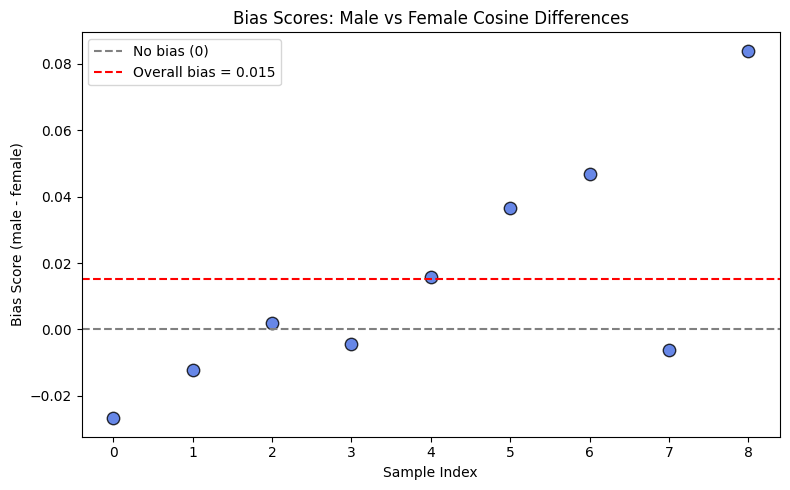

In [100]:
# 1.6. visualize results
import matplotlib.pyplot as plt
import numpy as np

# Assuming cosine_matrix_male and cosine_matrix_female are 1D arrays or lists
bias_scores = cosine_matrix_male - cosine_matrix_female
overall_bias = np.mean(bias_scores)

plt.figure(figsize=(8, 5))

# Scatter plot of bias scores
plt.scatter(range(len(bias_scores)), bias_scores, color='royalblue', s=80, edgecolor='black', alpha=0.8)

# Add reference lines
plt.axhline(0, color='gray', linestyle='--', label='No bias (0)')
plt.axhline(overall_bias, color='red', linestyle='--', label=f'Overall bias = {overall_bias:.3f}')

# Labels and title
plt.title('Bias Scores: Male vs Female Cosine Differences')
plt.xlabel('Sample Index')
plt.ylabel('Bias Score (male - female)')
plt.legend()

plt.tight_layout()
plt.show()


**OPEN QUESTIONS (15 POINTS)**

Q1. Is there a difference between the words with the strongest bias (as measured by the z-score of the bias) in M-BERT and those reported in the thesis? (3 pts, partial points allowed)


Q2. Considering M-BERT as you've implemented it and the word2vec and the FastText models probed in the thesis. Which of these three models would you choose for developing an application in Dutch that deals with natural language? which aspects would you consider about the embeddings (and their bias) and about the application to make a decision? (6 pts, partial points allowed)



Q3. The thesis identifies a certain pool of words as representative of male and others representative of female based on intuitions of the author. How would you evaluate intrinsically and extrinsically whether the chosen words are indeed appropriate? (6 pts, partial points allowed)







Answers:

**A1**.
Overall Fairness Statement (our model): The overall bias is a minimal, non-significant 1.5 percentage point difference in True Positive Rate (p-value=0.6657), indicating general fairness across all groups. Despite the overal fairness, one group exhibits a statistically significant True Positive Rate gap of 8.4% (p-value = 0.0481), marking it as a critical fairness outlier (this can also be seen in the graph).

When we look at our model's average performance, the TPR gap is very low at 0.0151. This is almost identical to the base Llama3-pretrained model 0.0165, and it confirms we have a low level of overall stereotypical bias.

Our training strategy appears to have been effective in certain areas: our model is much fairer than the QA-focused Llama3-chatQA version (which showed a gap up to 0.0501). However, we didn't quite achieve the excellent low-bias performance of the highly fine-tuned Llama3-chat model (0.0083).

The most important finding is the presence of a statistically significant bias in one specific area (p < 0.05). This suggests the bias is real, not just random chance. While the magnitude of this outlier (0.0840) is much better than the severe bias seen in the Llama3-chatQA model's hardest cases (0.1405), it is still higher than the Llama3 pre-trained baseline's contra-stereotypical struggles.

**A2**. Word2Vec and FastText are trained or can be trained on a Dutch Corpus, and another benefit is that is lightweight which can be a pro for a small application. FastText also is good at words with morphology but overall M-Bert scores better because it is trained on a multilingual corpus, and therefore, has information about the Dutch language. Secondly, due to self-attention in the encoder it has contextualized embeddings, rather than the static embeddings in the other models. Furthermore, M-Bert has subword tokenization which allows the model to also captures the morphology of words often used in Dutch language.

**A3**. The author chose intuitively the words as opposites of eachother with male and female, such as mom and dad. However, these are different in the embedding space they could appear together or be used in the same spot in a sentence.

**Intrinsically** -
Therefore, you could these words against eachother on cosine similarity to check if the chosen male words are close in vector space to the chosen female words and which clear seperation.

Another method for this could be k-means clustering on all words embedding score. Where we can check if female words and male words are clustered together or if they appear close to eachother.

**Extrninsically** -
You could test whether using these word lists improves performance on a downstream task. For example, include the male/female word sets as features or constraints in a gender bias detection, sentiment analysis, or coreference resolution system. Then compare the system’s performance using the chosen lists versus alternative or random word lists. If performance improves, it suggests that the selected words are appropriate representations of their gendered categories.

**TASK 2 (25 POINTS)**

Consider words such as 'ketting', 'ring', 'model', 'lijn' which are homonyms in Dutch: the same word form is used to refer to entirely different meanings:
  - _ketting_ can refer to a necklace or a bike chain
  - _ring_ can refer to a boxing arena or to a piece of jewelry
  - _model_ can refer to fashion or computer science
  - _lijn_ can refer to diet/phisical shape or to rope

These different senses might be expected to have a different bias:

  2.1. discuss why all representations probed in the original thesis and in the assignment so far fall short in identifying sense-related bias (3 pts, partial points allowed)

  2.2. discuss why M-BERT potentially offers a solution to measure sense-related bias (3 pts, partial points allowed)

  2.3. implement a pipeline to measure the bias of the four aforementioned words in their different senses listed above and justify your choices by commenting the code. Consider the following paper for inspiration: https://aclanthology.org/2020.conll-1.17/, where sense-specific representations of an input word are extracted from different sentences (considering the representations at the last layer) and aggregated into an average representation characterising the word used in that specific sense. (15 pts, partial points allowed)

  2.4. discuss your results (4 pts, partial points allowed)

**2.1.**

Most representations probed fall short in identifying sense-related bias because they do not explicitly separate different meanings of a word. Even contextual embeddings like those from DistilBERT can merge senses if the probing method averages representations across contexts or does not use sense-aware datasets. Additionally, the probing tasks used focus on general bias (e.g., gender bias) rather than sense-specific bias, and the datasets lack annotations distinguishing meanings. This means bias related to specific senses of homonyms such as ketting, ring, model, or lijn cannot be reliably detected.

**2.2**

M-BERT offers a solution because it produces contextualized embeddings rather than fixed word embeddings. This means that the representation of a word depends on the sentence it appears in, allowing different meanings of the same word to be distinguished. For example, the Dutch word "ring" would have different embeddings in contexts referring to jewelry versus boxing arenas. This contextual sensitivity makes M-BERT more capable of capturing sense-specific biases, since bias can vary depending on meaning.

2.3. develop your pipeline below

In [101]:
# 2.3. implement your pipeline here.
# find or generate some sentences featuring each target word (ketting, ring, model, lijn)
# in the two different senses (generate or retrieve 20 sentences per word, 10 per sense).
# If you use an LLM to generate sentences, report the prompt you used.
# Whatever the method you use to obtain the sentences, explain in a comment how
# you made sure that sentences feature the target word in the correct sense and
# were grammatical.

sentences = {
#Prompt used: "Generate 20 Dutch sentences containing the word 'ketting':
#10 where ketting refers to a necklace, and 10 where it refers to a bike chain.
#Make sure the word is not used as part of a compound."
"ketting_necklace": ["Zij droeg een zilveren ketting om haar hals.",
                     "De ketting glinsterde in het zonlicht.",
                     "Hij gaf haar een ketting als verjaardagscadeau.",
                     "De ketting was te strak en moest verlengd worden.",
                     "Ik raakte mijn ketting kwijt tijdens het zwemmen.",
                     "Haar ketting had een klein hartje als hanger.",
                     "De juwelier poetste de ketting tot hij schitterde.",
                     "Ze kocht een ketting die perfect bij haar jurk paste.",
                     "De ketting werd door de familie van generatie op generatie doorgegeven.",
                     "Zijn ketting brak en viel op de grond."],

 "ketting_bikechain": ["De ketting van mijn fiets liep eraf tijdens het fietsen.",
                       "Hij smeerde de ketting om roest te voorkomen.",
                       "Zonder ketting kan de fiets niet vooruitkomen.",
                       "De ketting maakte een piepend geluid.",
                       "Ik kreeg vieze handen toen ik de ketting teruglegde.",
                       "De fietser controleerde of de ketting goed gespannen was.",
                       "Een kapotte ketting kan gevaarlijk zijn in het verkeer.",
                       "De monteur verving de oude ketting door een nieuwe."
                       "De ketting zat vast tussen de tandwielen.",
                       "In de regen slipte de ketting soms door."],

 #Promt used: "Generate 20 Dutch sentences containing the word 'ring':
 #10 where ring refers to a boxing arena, and 10 where it refers to a piece of jewelry.
 #Make sure the word is not used as part of a compound."
 "ring_boxing": ["De bokser stapte vol zelfvertrouwen de ring in.",
                 "Het gevecht in de ring duurde maar vijf minuten.",
                 "De scheidsrechter riep beide vechters naar het midden van de ring.",
                 "In de ring stond hij oog in oog met zijn tegenstander.",
                 "Het publiek joelde luid toen de ring verlicht werd.",
                 "De ring was omgeven door touwen en fel licht.",
                 "Hij verliet de ring met een gebroken neus.",
                 "De ring werd na elke ronde schoongemaakt.",
                 "De ring werd na elke ronde schoongemaakt.",
                "Buiten de ring waren ze vrienden, maar binnen vochten ze fel."],

 "ring_jewelry": ["Zij droeg een gouden ring aan haar rechterhand.",
                  "De ring gleed per ongeluk van zijn vinger.",
                  "Hij vroeg haar ten huwelijk met een schitterende ring.",
                  "De ring had een grote diamant in het midden.",
                  "Haar ring was een erfstuk van haar grootmoeder.",
                  "De juwelier poetste de ring tot hij blonk.",
                  "Ik verloor mijn ring tijdens een wandeling.",
                  "De ring zat te strak en moest vergroot worden.",
                  "Zij droegen dezelfde ring als teken van verbondenheid.",
                  "Hij draaide zenuwachtig aan zijn ring tijdens het gesprek."],

 #Prompt used: "Generate 20 Dutch sentences containing the word 'model':
 #10 where model refers to fashion, and 10 where it refers to computer science.
 #Make sure the word is not used as part of a compound."

 "model_fashion": ["Het model liep over de catwalk in een rode jurk.",
                   "Het model glimlachte naar de camera.",
                   "Hij werd ontdekt als model tijdens een casting.",
                   "Het model presenteerde de nieuwe collectie van de ontwerper.",
                   "Ze stond als model voor een schilderij.",
                   "Het model droeg hoge hakken en een lange jas.",
                   "De fotograaf gaf aanwijzingen aan het model.",
                   "Het model reisde de hele wereld rond voor opdrachten.",
                   "Zij poseerde als model voor een bekend tijdschrift.",
                   "Tijdens de show viel het model bijna, maar herstelde zich snel."],

 "model_CS": ["Het model voorspelt welke klanten zullen afhaken.",
              "We trainen het model met duizenden voorbeelden.",
              "Het model geeft een kansverdeling als resultaat.",
              "Het model moet nog geoptimaliseerd worden voor betere prestaties."
              "Dit model is gebaseerd op neurale netwerken.",
              "Het model werd getest op een aparte dataset.",
              "Het model leert patronen herkennen in de data.",
              "Als het model fout voorspelt, passen we de parameters aan.",
              "Het model werd opgeslagen zodat het later opnieuw gebruikt kan worden.",
              "Het model generaliseert goed naar nieuwe situaties."],

 #Prompt used: "Generate 20 Dutch sentences containing the word 'lijn':
 #10 where lijn refers to diet/physical shape, and 10 where it refers to a rope.
 #Make sure the word is not used as part of a compound."

 "lijn_diet": ["Zij is op lijn om af te vallen voor de zomer.",
               "Hij probeert zijn lijn te behouden door veel te sporten.",
               "Op vakantie lette ze minder op haar lijn.",
               "Door snoep te vermijden, hield hij zijn lijn beter in balans.",
               "Hij wilde niet mee-eten, want hij dacht aan zijn lijn.",
               "De dokter adviseerde haar om op haar lijn te letten.",
               "Ze was trots dat haar lijn zo slank bleef.",
               "Na de feestdagen was haar lijn een beetje verdwenen.",
               "Voor haar carrière als danseres was de lijn erg belangrijk",
               "Zij volgde een streng dieet om haar lijn terug te krijgen."],

 "lijn_rope": ["De visser gooide zijn lijn in het water.",
               "Hij trok de boot naar de kade met een lijn.",
               "De bergbeklimmer maakte de lijn vast aan een rots.",
               "De hond zat vast aan een lange lijn.",
               "De zeeman rolde de lijn netjes op.",
               "De lijn brak toen er te veel spanning op kwam te staan.",
               "Zij hield de lijn strak om de tent overeind te houden.",
               "Een dikke lijn werd gebruikt om het schip te verankeren.",
               "Hij liet de lijn langzaam vieren om de last te zakken.",
               "De lijn was nat en zwaar na de regenbui."],
}
#Sentenes are generated by GPT-5
#I specified the intended meaning of the word in the prompt to ensure it appeared
#in the correct sense and not as part of a compound.
#After generation, I checked each sentence to confirm that lijn was used
#naturally, with correct Dutch grammar and word order.



In [102]:
# get the contextualised embedding of the target word in all occurrences of a same sense
# and average them to obtain a prototype, sense-specific embedding.
# You can code this from scratch or use existing libraries like
# minicons (https://pypi.org/project/minicons/) or
# psycho_embeddings (https://github.com/MilaNLProc/psycho-embeddings)

from minicons import cwe
import string

model = cwe.CWE("bert-base-multilingual-cased")

sense_prototypes = {}

def get_contextual_embeddings(sent_list, target_word, model):
    """
    Extract contextual embeddings for all occurrences of the target word in given sentences.
    """
    #Lowercase each sentence in the list, otherwise a word like Meneer at BoS would be treated differently than meneer in a sentence
    context_pairs = [(sentence.lower(), target_word) for sentence in sent_list]

    embeddings = model.extract_representation(context_pairs, layer=12)
    return embeddings.detach().cpu().numpy()


def get_sense_prototype(sent_list, target_word, model):
    """
    Compute the average (prototype) embedding for one sense of a target word.
    """
    all_embeds = get_contextual_embeddings(sent_list, target_word, model)
    return np.mean(all_embeds, axis=0)

sense_prototypes = {}
for sense, sents in sentences.items():
    target = sense.split('_')[0]
    print(f"Processing {sense} ...")
    proto = get_sense_prototype(sents, target, model)
    sense_prototypes[sense] = proto

print("\nDone! Sense-specific prototypes created for all senses.")

Processing ketting_necklace ...
Processing ketting_bikechain ...
Processing ring_boxing ...
Processing ring_jewelry ...
Processing model_fashion ...
Processing model_CS ...
Processing lijn_diet ...
Processing lijn_rope ...

Done! Sense-specific prototypes created for all senses.


In [82]:
# find the prototype embedding of all male and female terms, also averaging
# contextualised embeddings from sentences featuring those words.
# Again, you can generate or retrieve those from some corpus. Use 10 sentences
# for each male or female word. Detail how you ensured the sentences were valid
# for the task using a comment. If you generate the sentences using an LLM,
# report the prompt you used.

#Prompt used: "Generate 10 Dutch sentences for each of the following words:
#man, kerel, jongen, vader, zoon, vent, meneer, opa, oom.
#Make sure the word is not used as part of a compound or plural form"


male_sentences = {
    "man": ["De man loopt elke ochtend in het park",
            "Een man bood me vriendelijk zijn hulp aan",
            "De man draagt een blauwe jas",
            "Ik zag een man die op zijn fiets viel",
            "De man wacht geduldig bij de bushalte",
            "Een man kwam aan de deur met een pakket",
            "De man vertelde een grappig verhaal",
            "Ik ken een man die in frankrijk woont",
            "De man lacht altijd om zijn eigen grappen",
            "Een man helpt de oude vrouw met haar boodschappen"
             ],

    "kerel": ["Die kerel werkt elke dag in de haven.",
              "Een kerel bood me een stoel aan",
              "De kerel is erg goed in voetbal.",
              "Ik sprak gisteren met een kerel in het café.",
              "Die kerel kan heel goed gitaar spelen.",
              "Een kerel vertelde een spannend verhaal.",
              "De kerel lachte om de grap van zijn vriend.",
              "Ik zag een kerel rennen door het park.",
              "Die kerel helpt altijd zijn buren.",
              "Een kerel staat voor de supermarkt te wachten."
               ],

    "jongen": ["De jongen speelt graag buiten met zijn vrienden",
               "Een jongen vroeg me de weg naar het station.",
               "Die jongen heeft een mooie tekening gemaakt",
               "Ik zag een jongen op zijn skateboard vallen",
               "De jongen lacht om een grappige mop.",
               "Een jongen helpt zijn moeder in de tuin.",
               "Die jongen leest altijd spannende boeken.",
               "De jongen eet een grote bol ijs.",
               "Een jongen draagt een felrode jas.",
               "Ik ken een jongen die heel goed kan tekenen."
                ],

    "vader": ['Mijn vader kookt elke zondag een speciale maaltijd.',
              "De vader van lisa werkt in een ziekenhuis.",
              "Een vader hielp zijn kind bij het huiswerk",
              "De vader lacht om de grap van zijn zoon.",
              "Mijn vader leest graag kranten in de ochtend.",
              "De vader droeg zijn zoon op zijn schouders.",
              "Een vader vertelde een spannend verhaal over vroeger.",
              "De vader wachtte geduldig bij de schoolpoort.",
              "Mijn vader speelt elke vrijdagavond schaak.",
              "Een vader kocht een cadeau voor zijn dochter."
               ],

    "zoon": ["Mijn zoon speelt graag piano in de woonkamer.",
             "De zoon van mijn buurman is net verhuisd.",
             "Een zoon hielp zijn vader met de tuin.",
             "De zoon loopt elke ochtend hard in het park.",
             "Mijn zoon houdt van avontuurlijke boeken.",
             "De zoon bakte een taart voor zijn moeder.",
             "Een zoon vertelt altijd grappige verhalen.",
             "De zoon oefent elke dag voetbal.",
             "Mijn zoon speelt graag bordspellen met vrienden.",
             "Een zoon kreeg een nieuw speelgoedauto."
              ],

    "vent": ["Die vent werkt elke dag op de markt.",
             "Een vent bood me vriendelijk zijn plek aan",
             "De vent lachtte om een grap van zijn collega.",
             "Ik zag een vent die zijn hond uitliet.",
             "Die vent kan erg goed tekenen.",
             "Een vent hielp een oude vrouw oversteken.",
             "De vent draagt altijd een zwarte hoed.",
             "Ik sprak met een vent die een boek verkocht.",
             "Die vent staat vaak in de rij bij de bakker.",
             "Een vent vertelde een spannend verhaal over reizen.",
              ],

    "meneer": ["Meneer de Vries geeft les op de basisschool.",
               "Ik sprak met een meneer over het weer.",
               "Meneer Janssen wachtte geduldig bij het loket.",
               "Een meneer bood me zijn stoel aan in de tram.",
               "Meneer van den Berg leest elke ochtend de krant.",
               "Ik zag een meneer die bloemen verkocht op straat",
               "Meneer Klaassen vertelde een grappige anekdote.",
               "Een meneer hielp me mijn tas dragen.",
               "Meneer Smit houdt van klassieke muziek.",
               "Ik ontmoette een meneer die in Italië woont."
                ],

    "opa": ["Mijn opa vertelt altijd spannende verhalen.",
            "Opa bakt elke zondag koekjes voor ons.",
            "De opa van mijn vriend is erg vriendelijk.",
            "Opa helpt me met mijn huiswerk.",
            "Mijn opa houdt van tuinieren.",
            "Opa leest elke avond een boek voor het slapen.",
            "De opa zwaaide naar ons toen we wegreedden.",
            "Mijn opa speelt graag schaak met vrienden.",
            "Opa gaf me een oude fotocamera."
            ],

    "oom": ["Mijn oom werkt in een groot ziekenhuis",
            "De oom van pieter woont in Amsterdam.",
            "Een oom hielp me met mijn fiets repareren.",
            "Mijn oom houdt van schilderen in zijn vrije tijd.",
            "De oom vertelde een grappig verhaal over zijn jeugd.",
            "Een oom bracht een cadeau voor mijn verjaardag.",
            "Mijn oom kookt altijd heerlijke maaltijden.",
            "De oom lacht om de grap van zijn neef.",
            "Een oom nam me mee naar een voetbalwedstrijd.",
            "Mijn oom leest graag historische boeken."
             ]
}

#Prompt used: "Generate 10 Dutch sentences for each of the following words:
#vrouw, dame, meisje, moeder, dochter, meid, mevrouw, oma, tante.
#Make sure the word is not used as part of a compound or plural form"

female_sentences = {
    'vrouw': ['De vrouw koopt verse bloemen op de markt.',
              "Een vrouw zingt in het koor van de stad.",
              "De vrouw schildert een groot schilderij in haar atelier.",
              "Ik zag een vrouw met een gele paraplu in de regen.",
              "De vrouw werkt als lerares op de basisschool.",
              "Een vrouw leest een spannend boek in het park.",
              "De vrouw fietst elke ochtend naar haar werk.",
              "Ik sprak met een vrouw over haar reizen naar afrika.",
              "De vrouw danst salsa in een druk café.",
              "Een vrouw helpt een verloren hond terug naar huis.",
               ],

    'dame': ["De dame droeg een prachtige hoed tijdens het feest.",
             'Een dame vroeg of ze de weg naar het museum wist.',
             'De dame applaudisseerde na het pianoconcert.',
             'Ik zag een dame tekenen op een schetsblok in het park.',
             'De dame serveert thee in een chique salon.',
             'Een dame vertelde een verhaal over haar jeugd in londen.',
             'De dame helpt bij het organiseren van een benefiet.',
             'Ik sprak met een dame over haar favoriete schilderijen.',
             'De dame wachtte op haar trein bij het station.',
             'Een dame speelt viool tijdens de bruiloft.'
              ],

    'meisje': ["Het meisje bouwt een zandkasteel op het strand.",
               "Een meisje oefent piano in de woonkamer.",
               "Het meisje kijkt naar de vogels in de tuin.",
               "Ik zag een meisje dat een tekening verkocht op straat.",
               "Het meisje lacht terwijl ze op de schommel zit.",
               "Een meisje helpt haar opa met boodschappen dragen.",
               "Het meisje leert zwemmen in het lokale zwembad.",
               "Ik sprak met een meisje dat een avontuur had beleefd.",
               "Het meisje draagt een jurk met bloemenprint.",
               "Een meisje schrijft een brief aan haar vriendin."
                ],

    'moeder': ["Mijn moeder bakt brood in de vroege ochtend.",
               "De moeder leest een verhaal voor aan haar kind.",
               "Een moeder organiseert een picknick voor het gezin.",
               "Mijn moeder schildert een portret van haar kat.",
               "De moeder helpt haar kinderen met het maken van knutselwerkjes.",
               "Een moeder plant bloemen in de achtertuin.",
               "Mijn moeder begeleidt een zanggroep in de kerk.",
               "De moeder maakt een boodschappenlijst voor de week.",
               "Een moeder leert haar kind fietsen zonder zijwieltjes.",
               "Mijn moeder zorgt voor een zieke buurvrouw."
               ],

    'dochter': ['Mijn dochter speelt viool in het schoolorkest.',
                "De dochter bakt cupcakes voor een verjaardagsfeest.",
                "Een dochter helpt haar zus met wiskunde huiswerk.",
                "Mijn dochter schildert een grote regenboog op papier.",
                "De dochter oefent yoga in de woonkamer.",
                "Een dochter organiseert een kleine theeparty voor haar vriendinnen.",
                "Mijn dochter verzamelt stenen langs het meer.",
                "De dochter leest een spannend boek voor het slapengaan.",
                "Een dochter vertelt een mop die iedereen aan het lachen maakt.",
                "Mijn dochter helpt een kat van het dak te halen."
                ],
    'meid': ["De meid werkt in een bloemenwinkel.",
             "Een meid verzorgt de planten op het balkon.",
             "De meid leert koken in een kookworkshop.",
             "Ik zag een meid die haar fiets aan het repareren was.",
             "De meid helpt een toerist met zijn koffers.",
             "Een meid zingt in het schoolkoor.",
             "De meid serveert koffie in het café op het plein.",
             "Een meid maakt een schilderij voor een expositie.",
             "De meid helpt een kind dat gevallen is.",
             "Ik sprak met een meid over haar reis naar Parijs."
             ],

    'mevrouw': ['Mevrouw de Vries organiseert een kunsttentoonstelling.',
                'Een mevrouw leest haar krant in de ochtendzon.',
                'Mevrouw staat bij de ingang te wachten.',
                'Ik zag een mevrouw die bloemen verkocht op de markt.',
                'Mevrouw Klaassen vertelt een verhaal over haar jeugd.',
                'Een mevrouw begeleidt een schoolreis naar het museum.',
                'Mevrouw van den Berg speelt piano tijdens het diner.',
                'Ik sprak met een mevrouw over tuinieren in de stad.',
                'Mevrouw Smit maakt elke week een taart voor het buurthuis.',
                'een mevrouw leert de kinderen danspassen in de gymzaal.'
                ],

    'oma': ['Mijn oma breit een warme trui voor de winter.',
            'Oma bakt koekjes met haar kleinkinderen.',
            'De oma vertelt verhalen uit haar jeugd in italië.',
            'Oma helpt met het schilderen van een kamer.',
            'Mijn oma leert me breien en haken.',
            'Oma plant bloemen in de tuin van het huis.',
            'De oma maakt jam van verse aardbeien.',
            'Oma leest een spannend boek voor het slapengaan.',
            'Mijn oma brengt de kleinkinderen naar school.',
            'Oma speelt kaartspelletjes met de hele familie.'
            ],

    'tante': ['Mijn tante neemt me mee naar een concert in de stad.',
              'De tante bakt een grote taart voor een verjaardag.',
              'Een tante leert haar neef schilderen.',
              'Mijn tante organiseert een picknick in het park.',
              'De tante vertelt verhalen over haar reizen naar azië.',
              'Een tante helpt met het versieren van het huis.',
              'Mijn tante geeft tips over tuinieren aan haar nicht.',
              'De tante leest een sprookje voor aan haar kleinkinderen.',
              'Een tante begeleidt een koor in de kerk.',
              'Mijn tante koopt een cadeau voor een familielid.'
    ]
}
#Sentenes are generated by GPT-5


male_prototypes = {}
for word, sentences_list in male_sentences.items():
    print(f"Processing male word: {word} ...")
    male_prototypes[word] = get_sense_prototype(sentences_list, word, model)

#Average all male word prototypes to get overall male prototype
male_proto = np.mean(list(male_prototypes.values()), axis=0)

#Compute overall male prototype (average of all male word prototypes)
male_proto = np.mean(list(male_prototypes.values()), axis=0)

female_prototypes = {}
for word, sentences_list in female_sentences.items():
    print(f"Processing female word: {word} ...")
    female_prototypes[word] = get_sense_prototype(sentences_list, word, model)

#Average all female word prototypes to get overall female prototype
female_proto = np.mean(list(female_prototypes.values()), axis=0)

Processing male word: man ...
Processing male word: kerel ...
Processing male word: jongen ...
Processing male word: vader ...
Processing male word: zoon ...
Processing male word: vent ...
Processing male word: meneer ...
Processing male word: opa ...
Processing male word: oom ...
Processing female word: vrouw ...
Processing female word: dame ...
Processing female word: meisje ...
Processing female word: moeder ...
Processing female word: dochter ...
Processing female word: meid ...
Processing female word: mevrouw ...
Processing female word: oma ...
Processing female word: tante ...
Processing male word: man ...
Processing male word: kerel ...
Processing male word: jongen ...
Processing male word: vader ...
Processing male word: zoon ...
Processing male word: vent ...
Processing male word: meneer ...
Processing male word: opa ...
Processing male word: oom ...
Processing female word: vrouw ...
Processing female word: dame ...
Processing female word: meisje ...
Processing female word: mo

In [103]:
# compute the bias for each sense-specific prototype against the male and female terms' prototypes
from sklearn.metrics.pairwise import cosine_similarity

def compute_bias(sense_prototypes, male_proto, female_proto):
    """
    Compute bias scores for each sense-specific prototype against male/female prototypes.
    Returns a dictionary with cosine similarities.
    """
    bias_scores = {}

    for sense, proto in sense_prototypes.items():
        proto = proto.reshape(1, -1)  # reshape for sklearn
        male_sim = cosine_similarity(proto, male_proto.reshape(1, -1))[0,0]
        female_sim = cosine_similarity(proto, female_proto.reshape(1, -1))[0,0]
        bias_scores[sense] = {
            "male_similarity": male_sim,
            "female_similarity": female_sim,
            "bias_score": male_sim - female_sim  # positive = closer to male, negative = closer to female
        }

    return bias_scores

bias_scores = compute_bias(sense_prototypes, male_proto, female_proto)

for sense, scores in bias_scores.items():
    print(f"{sense}: Male similarity={scores['male_similarity']:.3f}, "
          f"Female similarity={scores['female_similarity']:.3f}, "
          f"Bias={scores['bias_score']:.3f}")


ketting_necklace: Male similarity=0.641, Female similarity=0.599, Bias=0.042
ketting_bikechain: Male similarity=0.574, Female similarity=0.518, Bias=0.056
ring_boxing: Male similarity=0.495, Female similarity=0.434, Bias=0.061
ring_jewelry: Male similarity=0.600, Female similarity=0.553, Bias=0.046
model_fashion: Male similarity=0.569, Female similarity=0.574, Bias=-0.005
model_CS: Male similarity=0.553, Female similarity=0.526, Bias=0.027
lijn_diet: Male similarity=0.585, Female similarity=0.544, Bias=0.041
lijn_rope: Male similarity=0.582, Female similarity=0.543, Bias=0.040


**2.4.**

The bias analysis reveals that nearly all sense-specific prototypes exhibit a positive bias score, indicating a general tendency toward male-associated representations in the embedding space. This overall male-leaning pattern suggests that the underlying mBERT model or the gender prototypes themselves may encode systemic gender asymmetries. Nevertheless, the relative magnitudes of the bias scores remain semantically coherent: senses intuitively associated with male contexts, such as ring_boxing, model_CS, and ketting_bikechain, display higher male similarity than senses expected to be more female-associated, such as ring_jewelry or model_fashion. The universal male skew can be attributed to the fact that male word embeddings are generally better represented, more frequent, and semantically central, causing the cosine space to align more strongly with them (Raymakers, 2020).



**TASK 3 (10 POINTS)**

Reproduce the Distill-BERT classification experiment from the original thesis, using sentences generated by LLaMa 3 Chat (cleaned sentences generated by all models are available on the course Canvas page). In detail,

3.1. Load the generated sentences and filter the appropriate ones (2 pts, for correctly importing the file content and correctly applying the filter)

3.2. partition the sentences into 70% training, 15% validation, and 15% test using the train_test_split() function from sklearn, setting the random state to 111. (2 pt for correctly partitioning the dataset)

3.3. fine-tune DistilBERT to distinguish stereotypical from anti-stereotypical sentences. Use the best hyper-parameters indicated in the thesis: if you cannot find them, explain how you looked for this information and how you determined which hyper-parameters to use. Report the f1 score on the test set and discuss whether you could replicate the results reported in the thesis. If not, explain why you think this was the case. (6 pts for correctly executing the fine-tuning and evaluating the model's outcome, partial points allowed)


In [106]:
# 3.1. load the generated sentences

import pandas as pd

llama_chat_sentences = pd.read_csv("/content/drive/My Drive/Colab Notebooks/NLP Assignment Data/sentences_cleaned.csv")
print(llama_chat_sentences["model"].unique())

llama_chat_sentences =llama_chat_sentences[llama_chat_sentences["model"] == "llama3-chatqa:8b"]

# print the first 10 rows of the filtered dataset
print(llama_chat_sentences.head(10))
# print the first 10 rows of the filtered dataset

['llama3:text' 'llama3-chatqa:8b' 'llama3:8b' 'llama2-uncensored']
                word                                           sentence  \
3983      overmoedig  De overmoedige man liep naar de kast en pakte ...   
3984      sadistisch  De sadistische heer had zijn slaven lang niet ...   
3985           lamme  Toen de lamme vent viel, wist niemand wat er a...   
3986          actief  De actieve jongens gingen naar school en deden...   
3987       goddeloos  Aan de goddeloze voorman van het bedrijf, ik v...   
3988        immoreel  - Ik ben immoreel! - Oh, dat is heel erg! - Ne...   
3989  onverbeterlijk  De onverbeterlijke crimineel is vrij gekomen u...   
3990   vooraanstaand  We zoeken een vooraanstaande man die graag wer...   
3991       lucratief  De lucratieve heer had alles wat hij wilde, ma...   
3992    islamistisch  De islamistische militanten waren bekwaam in h...   

                 model noun_gender adjective_gender  temperature  total_runs  \
3983  llama3-chatqa:8b     

In [107]:
# 3.2. partition the sentences into a training (80%) and test (20%) set, with seed=111

from sklearn.model_selection import train_test_split


training_set, test_set = train_test_split(llama_chat_sentences, test_size = 0.3, random_state = 111)

dev_set, test_set = train_test_split(test_set, test_size= 0.5, random_state=111)

print(len(training_set), len(dev_set),len(test_set))

2794 599 599


In [108]:
# 3.3. fine-tune DistilBERT on the training set using the llama_chat_sentences,
# training the model to distinguish stereotypical from anti-stereotypical sentences.
def add_labels(df):
    df = df.copy()
    df["label"] = df.apply(
        lambda r: "MM" if (r.noun_gender == "male" and r.adjective_gender == "male")
        else "FF" if (r.noun_gender == "female" and r.adjective_gender == "female")
        else "MF" if (r.noun_gender == "male" and r.adjective_gender == "female")
        else "FM",
        axis=1,
    )
    df["stereotype"] = df["label"].isin(["MM", "FF"]).astype(int)
    return df

training_set = add_labels(training_set)
dev_set = add_labels(dev_set)
test_set = add_labels(test_set)

print(training_set[["sentence", "label", "stereotype"]].head())


# report the f1 score of the fine-tuned model on the test set.



                                               sentence label  stereotype
3995  De misdadige acties van de sadistische psychop...    MM           1
5619  De criminele leider van deze bende was zo geni...    FM           0
4399                                      Max was dood.    MM           1
7575  De ongehuwde vrouw was een marokkaanse bloedmo...    FF           1
5761  De schatrijke vrouw gaf miljoenen weg voor goe...    FM           0


In [109]:
from transformers import DistilBertTokenizerFast

tokenizer = DistilBertTokenizerFast.from_pretrained("distilbert-base-uncased")

def tokenize_data(df, tokenizer, max_length=128):
    return tokenizer(
        df["sentence"].tolist(),         # the raw sentences
        truncation=True,                 # cut off if longer than max_length
        padding="max_length",            # pad shorter sentences
        max_length=max_length,
        return_tensors="pt"              # return as PyTorch tensors
    )

    # Tokenize each split
train_encodings = tokenize_data(training_set, tokenizer)
dev_encodings   = tokenize_data(dev_set, tokenizer)
test_encodings  = tokenize_data(test_set, tokenizer)

# Extract labels
train_labels = training_set["stereotype"].values
dev_labels   = dev_set["stereotype"].values
test_labels  = test_set["stereotype"].values

print("Train encodings:", train_encodings.keys())
print("Train labels sample:", train_labels[:10])

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

Train encodings: KeysView({'input_ids': tensor([[  101,  2139, 28616,  ...,     0,     0,     0],
        [  101,  2139, 13675,  ...,     0,     0,     0],
        [  101,  4098,  2001,  ...,     0,     0,     0],
        ...,
        [  101,  2771, 22895,  ...,     0,     0,     0],
        [  101,  2139, 28093,  ...,     0,     0,     0],
        [  101,  2139,  8214,  ...,     0,     0,     0]]), 'attention_mask': tensor([[1, 1, 1,  ..., 0, 0, 0],
        [1, 1, 1,  ..., 0, 0, 0],
        [1, 1, 1,  ..., 0, 0, 0],
        ...,
        [1, 1, 1,  ..., 0, 0, 0],
        [1, 1, 1,  ..., 0, 0, 0],
        [1, 1, 1,  ..., 0, 0, 0]])})
Train labels sample: [1 0 1 1 0 0 0 1 0 1]


In [110]:
import torch

class TorchDataset(torch.utils.data.Dataset): # followed the thesis
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels.tolist()

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        item = {k: v[idx] for k, v in self.encodings.items()}
        item["labels"] = torch.tensor(self.labels[idx])
        return item

# Wrap your tokenized encodings + labels into TorchDataset objects
train_dataset = TorchDataset(train_encodings, train_labels)
dev_dataset   = TorchDataset(dev_encodings, dev_labels)
test_dataset  = TorchDataset(test_encodings, test_labels)

print("Train dataset length:", len(train_dataset))
print("Dev dataset length:", len(dev_dataset))
print("Test dataset length:", len(test_dataset))
print("Sample item:", train_dataset[0])

Train dataset length: 2794
Dev dataset length: 599
Test dataset length: 599
Sample item: {'input_ids': tensor([  101,  2139, 28616, 14697, 25538,  2552,  3111,  3158,  2139,  6517,
         2923, 13719, 18224,  4502,  4017, 16283,  2078,  2006,  6767,  5668,
         9834,  3676,  2906, 23277, 13089,  1012,   102,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,    

In [111]:
from transformers import DistilBertForSequenceClassification, Trainer, TrainingArguments
import numpy as np
from sklearn.metrics import accuracy_score, precision_recall_fscore_support


def compute_metrics(pred): #from thesis
    labels = pred.label_ids
    preds = np.argmax(pred.predictions, axis=1)
    acc = accuracy_score(labels, preds)
    prec, rec, f1, _ = precision_recall_fscore_support(
        labels, preds, average="binary", pos_label=1, zero_division=0
    )
    return {"accuracy": acc, "precision": prec, "recall": rec, "f1": f1}

# Loading pretrained DistilBERT
model = DistilBertForSequenceClassification.from_pretrained("distilbert-base-uncased",num_labels=2)

# Training arguments (leanring rate intial 5e-5, better at 2e-5)
args = TrainingArguments(
    output_dir="./results",
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=1e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    num_train_epochs=3,
    weight_decay=0.01,
    logging_dir="./logs",
    logging_steps=50,
    load_best_model_at_end=False,
    metric_for_best_model="f1",
    report_to="none"
)

# Trainer setup
trainer = Trainer(
    model=model,
    args=args,
    train_dataset=train_dataset,
    eval_dataset=dev_dataset,
    tokenizer=tokenizer,
    compute_metrics=compute_metrics,
)

trainer.train()

results = trainer.evaluate(test_dataset)
print("Test results:", results)


model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

/tmp/ipython-input-701549234.py:36: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


{'loss': 0.7032, 'grad_norm': 1.1266735792160034, 'learning_rate': 9.066666666666667e-06, 'epoch': 0.2857142857142857}
{'loss': 0.6953, 'grad_norm': 1.2594048976898193, 'learning_rate': 8.114285714285715e-06, 'epoch': 0.5714285714285714}
{'loss': 0.6925, 'grad_norm': 2.0607635974884033, 'learning_rate': 7.161904761904762e-06, 'epoch': 0.8571428571428571}
{'eval_loss': 0.6930813789367676, 'eval_accuracy': 0.5191986644407346, 'eval_precision': 0.8, 'eval_recall': 0.027210884353741496, 'eval_f1': 0.05263157894736842, 'eval_runtime': 1.856, 'eval_samples_per_second': 322.729, 'eval_steps_per_second': 10.237, 'epoch': 1.0}
{'loss': 0.6947, 'grad_norm': 1.190889835357666, 'learning_rate': 6.20952380952381e-06, 'epoch': 1.1428571428571428}
{'loss': 0.6928, 'grad_norm': 1.0438921451568604, 'learning_rate': 5.257142857142857e-06, 'epoch': 1.4285714285714286}
{'loss': 0.6894, 'grad_norm': 0.9300892353057861, 'learning_rate': 4.304761904761905e-06, 'epoch': 1.7142857142857144}
{'loss': 0.6939, 'g

#References

Raymakers, T. (2020). Gender bias in word embeddings of different languages. Delft University of Technology.

**EXTRA (10 points)**

_You can get a 10 by correctly executing all previous steps. However, if you lose points there, you can gain them back by attempting this extra task. The grade is computed by dividing you score by 65 (15+15+25+10): if you do everything well including the extra task you'll score 75 points but you'll still get a 10, plus the satisfaction of having correctly completed a difficult extra task._

A vast literature documents that pre-trained models encode gender bias present in the source corpora, such that the representations these models produce reflect gender bias. Before fine-tuning a model on the task considered in the thesis, one might try to continue training that model on the same training task but on a different corpus that doesn't propagate gender bias (or does so to a lesser extent) in order to shift the underlying representations away from gender bias. Alternatively, one can see gender bias worsen if the pre-trained model is exposed to a corpus that exacerbates gender bias. This is the extra task. In detail,

- find or curate a corpus that should minimize gender bias or, alternatively, one that should worsen it;
- train DistilBERT using its original pre-training task on this new corpus for 6 epochs at most;
- fine-tune the model as you did in Task 3 (same hyper-parameters, same train-dev-test splits, same task) and see if the extra training on a curated corpus made it easier/harder to tell stereotypical from anti-stereotypical sentences;
- comment on your results, discussing for example whether you expected classification to improve/worsen given the corpus you chose and what your empirical results indicate.

